In [175]:
import polars as pl
import polars.selectors as cs
import pandas as pd
import seaborn as sns
import plotnine as p9

In [176]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# Lab 4.1.1 - Predicting Median Earnings by College Features

In this lab, we again build models that predict the median earnings of college graduates based on statistics on their respective college.

**Objectives.**
1. Visualize relationships with `seaborn`,
2. Build a `sklearn` preprocessing pipeline based on **1.**, and
3. Use a grid search to identify the best parameters.

#

## Step 1 - Load the data 

In [177]:
# Your code here
(college_earnings := pl.read_csv('data\\college_earnings (1).csv').filter(pl.col('FundingModel') != 'Private For-Profit')).head()

FundingModel,AdmissionRate,ACTMedian,SATAverage,AverageCost,MedianEarnings
str,f64,i64,i64,i64,i64
"""Public""",0.8989,17,823,18888,27000
"""Public""",0.8673,25,1146,19990,37200
"""Public""",0.8062,26,1180,20306,41500
"""Public""",0.5125,17,830,17400,22400
"""Public""",0.5655,26,1171,26717,39200


## Step 2 - Visualize the relationships

**Note.** Use `lmplot` to visualize the relationships between the features and the target variable. 

Be sure 
1. Filter out the private-for-profit colleges, and
2. to facet on the funding model (public vs. private) to illustrate any interactions/non-linearities.

In [178]:
# Your code here
(earnings_stacked := college_earnings.unpivot(
    cs.numeric() - cs.by_name('MedianEarnings'),    
    index=cs.string() | cs.by_name('MedianEarnings'),
    variable_name='feature',
    value_name='value')).head(3)

FundingModel,MedianEarnings,feature,value
str,i64,str,f64
"""Public""",27000,"""AdmissionRate""",0.8989
"""Public""",37200,"""AdmissionRate""",0.8673
"""Public""",41500,"""AdmissionRate""",0.8062


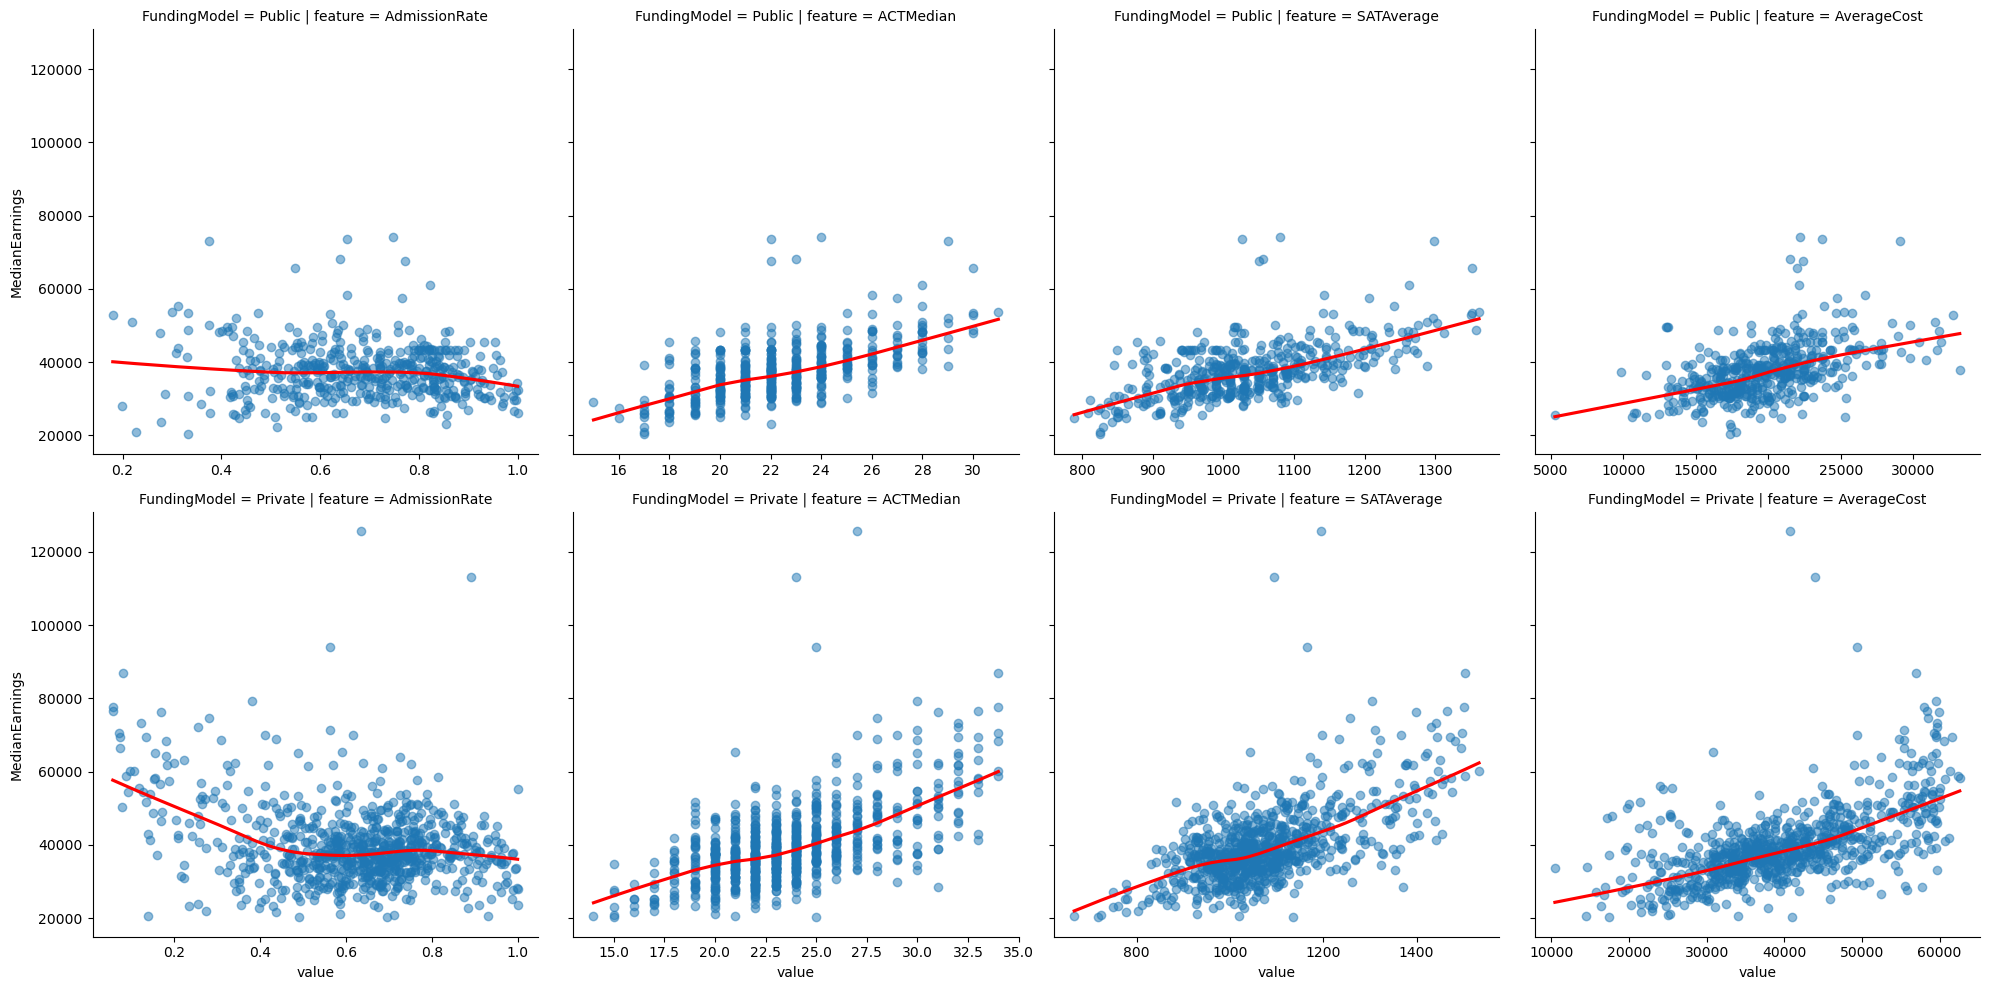

In [179]:
sns.lmplot(
    data=earnings_stacked.to_pandas(),
    y='MedianEarnings',
    x='value',
    col='feature',
    row = 'FundingModel',
    lowess=True,
    facet_kws={'sharex': False},
    scatter_kws={'alpha': 0.5},
    line_kws={'color': 'red'})

## Step 3 - Make lists of features by type.

Next we want to make lists of the
1. Numeric features,
2. Categorical features,
3. Linear features

In [180]:
(nonlin_features := college_earnings
    .select(cs.numeric() - cs.by_name('MedianEarnings', 'ACTMedian', 'SATAverage'))
    .columns
)

['AdmissionRate', 'AverageCost']

In [181]:
# Your code here (make new cells as needed.)
(cat_features := college_earnings
    .select(cs.string())
    .columns)

['FundingModel']

In [182]:
(lin_features := ['ACTMedian', 'SATAverage'])

['ACTMedian', 'SATAverage']

## Step 4 - Create the `X` and `y` data structures.

In [183]:
# Define X_earnings
(X_earnings := 
 college_earnings
 .drop('MedianEarnings')
 .to_pandas())

,FundingModel,AdmissionRate,ACTMedian,SATAverage,AverageCost
0,Public,0.8989,17,823,18888
1,Public,0.8673,25,1146,19990
2,Public,0.8062,26,1180,20306
3,Public,0.5125,17,830,17400
4,Public,0.5655,26,1171,26717
...,...,...,...,...,...
1280,Public,0.6579,22,1024,18097
1281,Public,0.4207,22,1015,13099
1282,Public,0.5940,24,1020,12946
1283,Public,0.4107,21,1017,13028


In [184]:
# Define y_earnings
(y_earnings := college_earnings
    .select('MedianEarnings')
    .to_numpy()
    .ravel()
)

array([27000, 37200, 41500, ..., 49700, 49700, 35800], shape=(1285,))

In [185]:
# Create training and test data
X_train, X_test, y_train, y_test = train_test_split(X_earnings, y_earnings, test_size=0.2, random_state=927)

In [186]:
(rate :=
    ['AdmissionRate']

)

['AdmissionRate']

In [187]:
(cost := 
    ['AverageCost']
 )

['AverageCost']

## Step 5a - Create pipelines for each type of feature.

1. Categorical features $\longrightarrow$ `OneHotEncoder`.
2. Linear features $\longrightarrow$ `StandardScaler`.
3. Scaled polynomial feature $\longrightarrow$ `StandardScaler` $\longrightarrow$ `PolynomialFeatures`.
4. Un-scaled polynomial feature $\longrightarrow$ `PolynomialFeatures`.

In [188]:
# Degine the categorial transformer
(cat_transformer := 
    make_pipeline(OneHotEncoder(handle_unknown='ignore')))

,steps,"[('onehotencoder', ...)]"
,transform_input,None
,memory,None
,verbose,False
,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None


In [189]:
# Define the linear transformer
(lin_transformer := 
    make_pipeline(StandardScaler())
)

,steps,"[('standardscaler', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True


In [190]:
# Define the polynomial transformer
(non_linear := 
    make_pipeline(StandardScaler(), 
                  PolynomialFeatures(degree=2, include_bias=False))
)

,steps,"[('standardscaler', ...), ('polynomialfeatures', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,degree,2
,interaction_only,False
,include_bias,False
,order,'C'


In [191]:
(poly_transformer_unscaled := 
    make_pipeline(PolynomialFeatures(degree=2, include_bias=False))
)

,steps,"[('polynomialfeatures', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,False
,include_bias,False
,order,'C'


## Step 5b - Combine the various transformers

Notes.  

1. We want to compare the performance of all our regressors covered in class,
2. Tree based models, like `RandomForestRegressor`, are not sensitive to the scale of the features, so we can skip the scaling step for those models.
3. For shrinkage models, like `Ridge` and `Lasso`, we can apply one polynomial feature transformation to all features, and let the model determine which features to use and how to use them.  
4. For tree-based models, we can also apply one polynomial feature transformation to all features, and let the model determine which features to use and how to use them.  

In [192]:
(interactions := Pipeline(steps=[
    ('non_linear', PolynomialFeatures(degree=2, interaction_only=True))])
)

,steps,"[('non_linear', ...)]"
,transform_input,None
,memory,None
,verbose,False
,degree,2
,interaction_only,True
,include_bias,True
,order,'C'


In [193]:
# Build the combined preprocessor here (add cells as needed)
from sklearn.compose import ColumnTransformer
(lin_preprocessor := 
    Pipeline(steps=[
        ('by_columns', ColumnTransformer(
            [
                ('cat', cat_transformer, cat_features),
                ('lin', lin_transformer, lin_features),
                ('cost', non_linear, cost),
                ('rate', non_linear, rate),
            ]
        )),
        ('interaction', interactions),
    ])
)

,steps,"[('by_columns', ...), ('interaction', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('lin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [194]:
(shrink_preprocessor := 
    Pipeline(steps=[
        ('by_columns', ColumnTransformer(
            [
                ('cat', cat_transformer, cat_features),
                ('poly_scaled', non_linear, nonlin_features),
            ]
        )),
    ])
)

,steps,"[('by_columns', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('poly_scaled', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [195]:
(tree_preprocessor := 
    Pipeline(steps=[
        ('by_columns', ColumnTransformer(
        [
        ('cat', cat_transformer, cat_features),
        ],
        remainder='passthrough')
        ), 
        ('interaction', interactions),
    ]
))

,steps,"[('by_columns', ...), ('interaction', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## Step 5c - Combine the preprocessor and regression model.

**Note.** It is good practice to test `model.fit(...)` here to identify any bugs.

In [196]:
# Combined the preprocessor and regression mode (add cells as needed)l
(lin_model := make_pipeline(lin_preprocessor, LinearRegression()))

,steps,"[('pipeline', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('by_columns', ...), ('interaction', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('lin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3


In [197]:
(kNN_model := make_pipeline(lin_preprocessor, KNeighborsRegressor()))

,steps,"[('pipeline', ...), ('kneighborsregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('by_columns', ...), ('interaction', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('lin', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3


In [198]:
(ridge_model := make_pipeline(shrink_preprocessor, Ridge()))

,steps,"[('pipeline', ...), ('ridge', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('by_columns', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('poly_scaled', ...)]"
,remainder,'drop'
,sparse_threshold,0.3


In [199]:
(lasso_model := make_pipeline(shrink_preprocessor, Lasso()))

,steps,"[('pipeline', ...), ('lasso', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('by_columns', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('poly_scaled', ...)]"
,remainder,'drop'
,sparse_threshold,0.3


In [200]:
(decision_tree_model := make_pipeline(tree_preprocessor, DecisionTreeRegressor()))

,steps,"[('pipeline', ...), ('decisiontreeregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('by_columns', ...), ('interaction', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3


In [201]:
(random_forest_model := make_pipeline(tree_preprocessor, RandomForestRegressor(random_state=927)))

,steps,"[('pipeline', ...), ('randomforestregressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('by_columns', ...), ('interaction', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3


## Step 6 - Build a combined grid of parameters and grid search

In [202]:
# Use model.get_params() to identify parameters
lin_model.get_params()

{'memory': None,
 'steps': [('pipeline', Pipeline(steps=[('by_columns',
                    ColumnTransformer(transformers=[('cat',
                                                     Pipeline(steps=[('onehotencoder',
                                                                      OneHotEncoder(handle_unknown='ignore'))]),
                                                     ['FundingModel']),
                                                    ('lin',
                                                     Pipeline(steps=[('standardscaler',
                                                                      StandardScaler())]),
                                                     ['ACTMedian', 'SATAverage']),
                                                    ('cost',
                                                     Pipeline(steps=[('standardscaler',
                                                                      StandardScaler()),
                                    

In [203]:
(generic_reg := Pipeline([
    ("preprocessor", None),
    ("regressor", None)
]))

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False


In [204]:
(lin_grid := {
    "preprocessor": [lin_preprocessor],
    "regressor": [LinearRegression()]
})

{'preprocessor': [Pipeline(steps=[('by_columns',
                   ColumnTransformer(transformers=[('cat',
                                                    Pipeline(steps=[('onehotencoder',
                                                                     OneHotEncoder(handle_unknown='ignore'))]),
                                                    ['FundingModel']),
                                                   ('lin',
                                                    Pipeline(steps=[('standardscaler',
                                                                     StandardScaler())]),
                                                    ['ACTMedian', 'SATAverage']),
                                                   ('cost',
                                                    Pipeline(steps=[('standardscaler',
                                                                     StandardScaler()),
                                                                    ('

In [205]:
(knn_grid := {
    "preprocessor": [lin_preprocessor],
    "regressor": [KNeighborsRegressor()],
    "regressor__n_neighbors": [3, 5, 7, 11, 15]
})


{'preprocessor': [Pipeline(steps=[('by_columns',
                   ColumnTransformer(transformers=[('cat',
                                                    Pipeline(steps=[('onehotencoder',
                                                                     OneHotEncoder(handle_unknown='ignore'))]),
                                                    ['FundingModel']),
                                                   ('lin',
                                                    Pipeline(steps=[('standardscaler',
                                                                     StandardScaler())]),
                                                    ['ACTMedian', 'SATAverage']),
                                                   ('cost',
                                                    Pipeline(steps=[('standardscaler',
                                                                     StandardScaler()),
                                                                    ('

In [206]:
(ridge_grid := {
    "preprocessor": [shrink_preprocessor],
    "regressor": [Ridge()],
    "regressor__alpha": [0.01, 0.1, 1, 10, 100]
})

{'preprocessor': [Pipeline(steps=[('by_columns',
                   ColumnTransformer(transformers=[('cat',
                                                    Pipeline(steps=[('onehotencoder',
                                                                     OneHotEncoder(handle_unknown='ignore'))]),
                                                    ['FundingModel']),
                                                   ('poly_scaled',
                                                    Pipeline(steps=[('standardscaler',
                                                                     StandardScaler()),
                                                                    ('polynomialfeatures',
                                                                     PolynomialFeatures(include_bias=False))]),
                                                    ['AdmissionRate',
                                                     'AverageCost'])]))])],
 'regressor': [Ridge()],
 'regre

In [207]:
(lasso_grid := {
    "preprocessor": [shrink_preprocessor],
    "regressor": [Lasso(max_iter=10000)],
    "regressor__alpha": [0.001, 0.01, 0.1, 1, 10],
})

{'preprocessor': [Pipeline(steps=[('by_columns',
                   ColumnTransformer(transformers=[('cat',
                                                    Pipeline(steps=[('onehotencoder',
                                                                     OneHotEncoder(handle_unknown='ignore'))]),
                                                    ['FundingModel']),
                                                   ('poly_scaled',
                                                    Pipeline(steps=[('standardscaler',
                                                                     StandardScaler()),
                                                                    ('polynomialfeatures',
                                                                     PolynomialFeatures(include_bias=False))]),
                                                    ['AdmissionRate',
                                                     'AverageCost'])]))])],
 'regressor': [Lasso(max_iter=10

In [208]:
(tree_grid := {
    "preprocessor": [tree_preprocessor],
    "regressor": [DecisionTreeRegressor(random_state=927)],
    "regressor__max_depth": [None, 3, 5, 10],
    "regressor__min_samples_leaf": [1, 3, 10]
})

{'preprocessor': [Pipeline(steps=[('by_columns',
                   ColumnTransformer(remainder='passthrough',
                                     transformers=[('cat',
                                                    Pipeline(steps=[('onehotencoder',
                                                                     OneHotEncoder(handle_unknown='ignore'))]),
                                                    ['FundingModel'])])),
                  ('interaction',
                   Pipeline(steps=[('non_linear',
                                    PolynomialFeatures(interaction_only=True))]))])],
 'regressor': [DecisionTreeRegressor(random_state=927)],
 'regressor__max_depth': [None, 3, 5, 10],
 'regressor__min_samples_leaf': [1, 3, 10]}

In [209]:
(forest_grid := {
    "preprocessor": [tree_preprocessor],
    "regressor": [RandomForestRegressor(random_state=927)],
    "regressor__n_estimators": [200, 500],
    "regressor__max_depth": [None, 5, 10],
    "regressor__min_samples_leaf": [1, 3]
})

{'preprocessor': [Pipeline(steps=[('by_columns',
                   ColumnTransformer(remainder='passthrough',
                                     transformers=[('cat',
                                                    Pipeline(steps=[('onehotencoder',
                                                                     OneHotEncoder(handle_unknown='ignore'))]),
                                                    ['FundingModel'])])),
                  ('interaction',
                   Pipeline(steps=[('non_linear',
                                    PolynomialFeatures(interaction_only=True))]))])],
 'regressor': [RandomForestRegressor(random_state=927)],
 'regressor__n_estimators': [200, 500],
 'regressor__max_depth': [None, 5, 10],
 'regressor__min_samples_leaf': [1, 3]}

In [210]:
combined_full_grids = [
    lin_grid,
    knn_grid,
    ridge_grid,
    lasso_grid,
    tree_grid,
    forest_grid
]

In [211]:
cv = KFold(n_splits=5, shuffle=True, random_state=927)

In [212]:
# Preform the grid search
(combined_full_grid_search := GridSearchCV(
    estimator=generic_reg,
    param_grid=combined_full_grids,
    scoring="neg_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    verbose=1
))

,estimator,"Pipeline(step...ssor', None)])"
,param_grid,"[{'preprocessor': [Pipeline(step...ly=True))]))])], 'regressor': [LinearRegression()]}, {'preprocessor': [Pipeline(step...ly=True))]))])], 'regressor': [KNeighborsRegressor()], 'regressor__n_neighbors': [3, 5, ...]}, ...]"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


In [213]:
(combined_full_grid_search.fit(X_train, y_train))

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,estimator,"Pipeline(step...ssor', None)])"
,param_grid,"[{'preprocessor': [Pipeline(step...ly=True))]))])], 'regressor': [LinearRegression()]}, {'preprocessor': [Pipeline(step...ly=True))]))])], 'regressor': [KNeighborsRegressor()], 'regressor__n_neighbors': [3, 5, ...]}, ...]"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,steps,"[('by_columns', ...), ('interaction', ...)]"


In [214]:
combined_full_grid_search.best_params_

{'preprocessor': Pipeline(steps=[('by_columns',
                  ColumnTransformer(remainder='passthrough',
                                    transformers=[('cat',
                                                   Pipeline(steps=[('onehotencoder',
                                                                    OneHotEncoder(handle_unknown='ignore'))]),
                                                   ['FundingModel'])])),
                 ('interaction',
                  Pipeline(steps=[('non_linear',
                                   PolynomialFeatures(interaction_only=True))]))]),
 'regressor': RandomForestRegressor(random_state=927),
 'regressor__max_depth': 5,
 'regressor__min_samples_leaf': 3,
 'regressor__n_estimators': 500}

## Step 7 - Validate the performance of the best model on the test set.

In [215]:
# Your code here (add cells as needed)
(y_pred :=combined_full_grid_search.predict(X_test))

array([35191.96604556, 39227.17304747, 33784.4120112 , 47447.15412212,
       36664.81839538, 38486.93213201, 37532.19339934, 56053.7870324 ,
       36969.83000921, 34844.48844323, 47633.95163912, 37283.87127105,
       38446.87258321, 48078.21798302, 35653.33915814, 37174.04657724,
       35251.45391258, 46088.72095686, 34975.72382248, 35723.19437512,
       35205.93791344, 35194.23777951, 38128.84675327, 33730.18637469,
       35942.06874296, 39120.21301664, 46631.2603031 , 36132.25418455,
       41872.07821224, 35044.51865322, 36833.04259352, 25729.09596953,
       36180.73864843, 48160.94186225, 44490.33118249, 34011.02748964,
       61711.50631673, 48568.32198911, 35280.33165864, 41913.20522298,
       34250.20723274, 43571.24276072, 35115.69618054, 35607.93155405,
       38781.21110145, 36117.54060015, 34364.20815296, 40092.58007973,
       31567.07302976, 38755.17371138, 34436.03722698, 36189.99004606,
       52816.35980263, 37936.95421855, 37396.31722942, 34781.28473271,
      

In [216]:
mean_absolute_error(y_pred, y_test)

5559.768858505027

In [217]:
mean_squared_error(y_pred, y_test)

76746769.0997104

In [218]:
74589079.81305036 ** 0.5

8636.496964224

In [219]:
combined_full_grid_search.best_estimator_.score(X_test, y_test)

0.21694874611667248

<font color = "orange">
The winning model was random features, but the results suggest only moderate predictive power. It achieved a test MAE of about $5,435, meaning its predictions were off by roughly $5.4k on average, and an MSE of about 76,745,769, which corresponds to an RMSE of about $8.6k. Its score of 0.22 indicates that it explains about 22% of the variation in median earnings, so it captures some useful signal but leaves a lot of unexplained variation. Overall, random forests was the best of the models, but the fit is still fairly limited for this dataset.
<font>

## Step 8 - Use the best Random Forest and Lasso models to identify the most important features.
**Note.** Write a summary comparing the features identified as important by the two models.

In [221]:
from sklearn.base import clone

(top_n := 10)

(cv_df := pd.DataFrame(combined_full_grid_search.cv_results_).assign(
    regressor_name=lambda d: d["param_regressor"].astype(str)
))

(rf_best_params := (
    cv_df[cv_df["regressor_name"].str.contains("RandomForestRegressor", na=False)]
    .sort_values("mean_test_score", ascending=False)
    .iloc[0]["params"]
))

(lasso_best_params := (
    cv_df[cv_df["regressor_name"].str.contains("Lasso", na=False)]
    .sort_values("mean_test_score", ascending=False)
    .iloc[0]["params"]
))

{'preprocessor': Pipeline(steps=[('by_columns',
                  ColumnTransformer(transformers=[('cat',
                                                   Pipeline(steps=[('onehotencoder',
                                                                    OneHotEncoder(handle_unknown='ignore'))]),
                                                   ['FundingModel']),
                                                  ('poly_scaled',
                                                   Pipeline(steps=[('standardscaler',
                                                                    StandardScaler()),
                                                                   ('polynomialfeatures',
                                                                    PolynomialFeatures(include_bias=False))]),
                                                   ['AdmissionRate',
                                                    'AverageCost'])]))]),
 'regressor': Lasso(max_iter=10000),
 'regres

In [222]:
(best_forest := clone(generic_reg).set_params(**rf_best_params)).fit(X_train, y_train)
(best_lasso := clone(generic_reg).set_params(**lasso_best_params)).fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('by_columns', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('poly_scaled', ...)]"
,remainder,'drop'
,sparse_threshold,0.3


In [223]:
(rf_feature_names := best_forest.named_steps["preprocessor"].get_feature_names_out())
(rf_importances := best_forest.named_steps["regressor"].feature_importances_)

(lasso_feature_names := best_lasso.named_steps["preprocessor"].get_feature_names_out())
(lasso_coefs := best_lasso.named_steps["regressor"].coef_)

array([-9599.99814977,     0.        ,  -739.50234032,  7644.79527082,
         509.75749779,  -469.45466888,  -160.74783888])

In [226]:
(rf_top_features := (
    pl.DataFrame(
        {
            "model": ["RandomForest"] * len(rf_feature_names),
            "feature": rf_feature_names,
            "importance": rf_importances,
            "direction": [float("nan")] * len(rf_feature_names),
        }
    )
    .sort("importance", descending=True)
    .head(top_n)
))

model,feature,importance,direction
str,str,f64,f64
"""RandomForest""","""remainder__SATAverage""",0.319741,NaN
"""RandomForest""","""remainder__SATAverage remainde…",0.204819,NaN
"""RandomForest""","""remainder__ACTMedian remainder…",0.183782,NaN
"""RandomForest""","""remainder__ACTMedian remainder…",0.053912,NaN
"""RandomForest""","""cat__FundingModel_Public remai…",0.036011,NaN
"""RandomForest""","""cat__FundingModel_Private rema…",0.035434,NaN
"""RandomForest""","""remainder__AverageCost""",0.033974,NaN
"""RandomForest""","""remainder__AdmissionRate remai…",0.024196,NaN
"""RandomForest""","""cat__FundingModel_Private rema…",0.021787,NaN


In [227]:
(lasso_top_features := (
    pl.DataFrame(
        {
            "model": ["Lasso"] * len(lasso_feature_names),
            "feature": lasso_feature_names,
            "importance": abs(lasso_coefs),
            "direction": lasso_coefs,
        }
    )
    .sort("importance", descending=True)
    .head(top_n)
))

model,feature,importance,direction
str,str,f64,f64
"""Lasso""","""cat__FundingModel_Private""",9599.99815,-9599.99815
"""Lasso""","""poly_scaled__AverageCost""",7644.795271,7644.795271
"""Lasso""","""poly_scaled__AdmissionRate""",739.50234,-739.50234
"""Lasso""","""poly_scaled__AdmissionRate^2""",509.757498,509.757498
"""Lasso""","""poly_scaled__AdmissionRate Ave…",469.454669,-469.454669
"""Lasso""","""poly_scaled__AverageCost^2""",160.747839,-160.747839
"""Lasso""","""cat__FundingModel_Public""",0.0,0.0


In [228]:
(rf_top5 := rf_top_features.select(["feature", "importance"]).head(5))
(lasso_top5 := lasso_top_features.select(["feature", "importance", "direction"]).head(5))

rf_top5, lasso_top5

(shape: (5, 2)
 ┌─────────────────────────────────┬────────────┐
 │ feature                         ┆ importance │
 │ ---                             ┆ ---        │
 │ str                             ┆ f64        │
 ╞═════════════════════════════════╪════════════╡
 │ remainder__SATAverage           ┆ 0.319741   │
 │ remainder__SATAverage remainde… ┆ 0.204819   │
 │ remainder__ACTMedian remainder… ┆ 0.183782   │
 │ remainder__ACTMedian remainder… ┆ 0.053912   │
 │ cat__FundingModel_Public remai… ┆ 0.036011   │
 └─────────────────────────────────┴────────────┘,
 shape: (5, 3)
 ┌─────────────────────────────────┬─────────────┬─────────────┐
 │ feature                         ┆ importance  ┆ direction   │
 │ ---                             ┆ ---         ┆ ---         │
 │ str                             ┆ f64         ┆ f64         │
 ╞═════════════════════════════════╪═════════════╪═════════════╡
 │ cat__FundingModel_Private       ┆ 9599.99815  ┆ -9599.99815 │
 │ poly_scaled__AverageCost  

### Step 8 Summary: Comparing Random Forest vs Lasso Features
- **Random Forest:** The strongest predictors are SAT/ACT variables and their interaction terms, which suggests academic readiness is the most important nonlinear signal in this model.
- **Lasso:** The largest effects are `FundingModel_Private` (negative), `AverageCost` (positive), and `AdmissionRate` terms (mixed linear/quadratic effects), showing a strong role for school type and cost.
- **Overall:** Both models agree that a small set of variables drives most predictive signal, but they emphasize different aspects. Random Forest highlights flexible interaction patterns, while Lasso gives a simpler directional story for key features.